# Market Microstructure + Game-Theory Execution Toy Model

**Author:** Sacha Loeb

This notebook runs the full analysis pipeline: sweep across 4 regimes × 3 strategies × 6 order sizes,
then builds the game-theory payoff matrix and finds Nash equilibria.

## 1. Problem

When should a trader use a market order vs a limit order? The answer depends on microstructure:
spread width, price impact, and order arrival rates. This simulator quantifies the tradeoff
across four regimes and interprets incentives via a 2-player game (LP vs LT).

## 2. Model & Assumptions

- **Approach:** Time-sliced (fixed Δt ticks), Poisson order arrivals, FIFO matching
- **Regimes:** A (tight/low), B (wide/low), C (tight/high), D (wide/high)
- **Strategies:** Pure market, pure limit, hybrid (passive then aggressive at 20% remaining time)
- **Metrics:** Implementation shortfall, slippage (bps), fill rate, time-to-fill
- **Game theory:** 2×3 normal-form game (LP chooses spread, LT chooses strategy), Nash via iterated best response

See [README.md](../README.md) for full assumptions and the 10-point limitations section.

## 3. Run Sweep

Set `n_runs=3` for a fast demo (~30s). For publication-quality confidence intervals, change to `n_runs=30` (~5 min).

In [1]:
import os
from pathlib import Path

# Ensure we run from the repo root so all relative paths resolve correctly
os.chdir(Path(os.path.abspath("")).parent if os.path.basename(os.path.abspath("")) == "notebooks" else ".")

from lob_simulator.runner import SweepConfig, load_regimes, run_sweep

# Change to 30 for full reproducibility
N_RUNS = 3

regimes = load_regimes()
cfg = SweepConfig(n_runs=N_RUNS)
df = run_sweep(cfg, regimes, results_dir=Path("results"))
print(f"Sweep complete: {len(df)} rows, {N_RUNS} runs/cell")

[regime_D | hybrid | size=50.0] 3/3: 100%|██████████| 216/216 [00:18<00:00, 11.71it/s]

Sweep complete: 72 rows, 3 runs/cell


## 4. Slippage vs Order Size

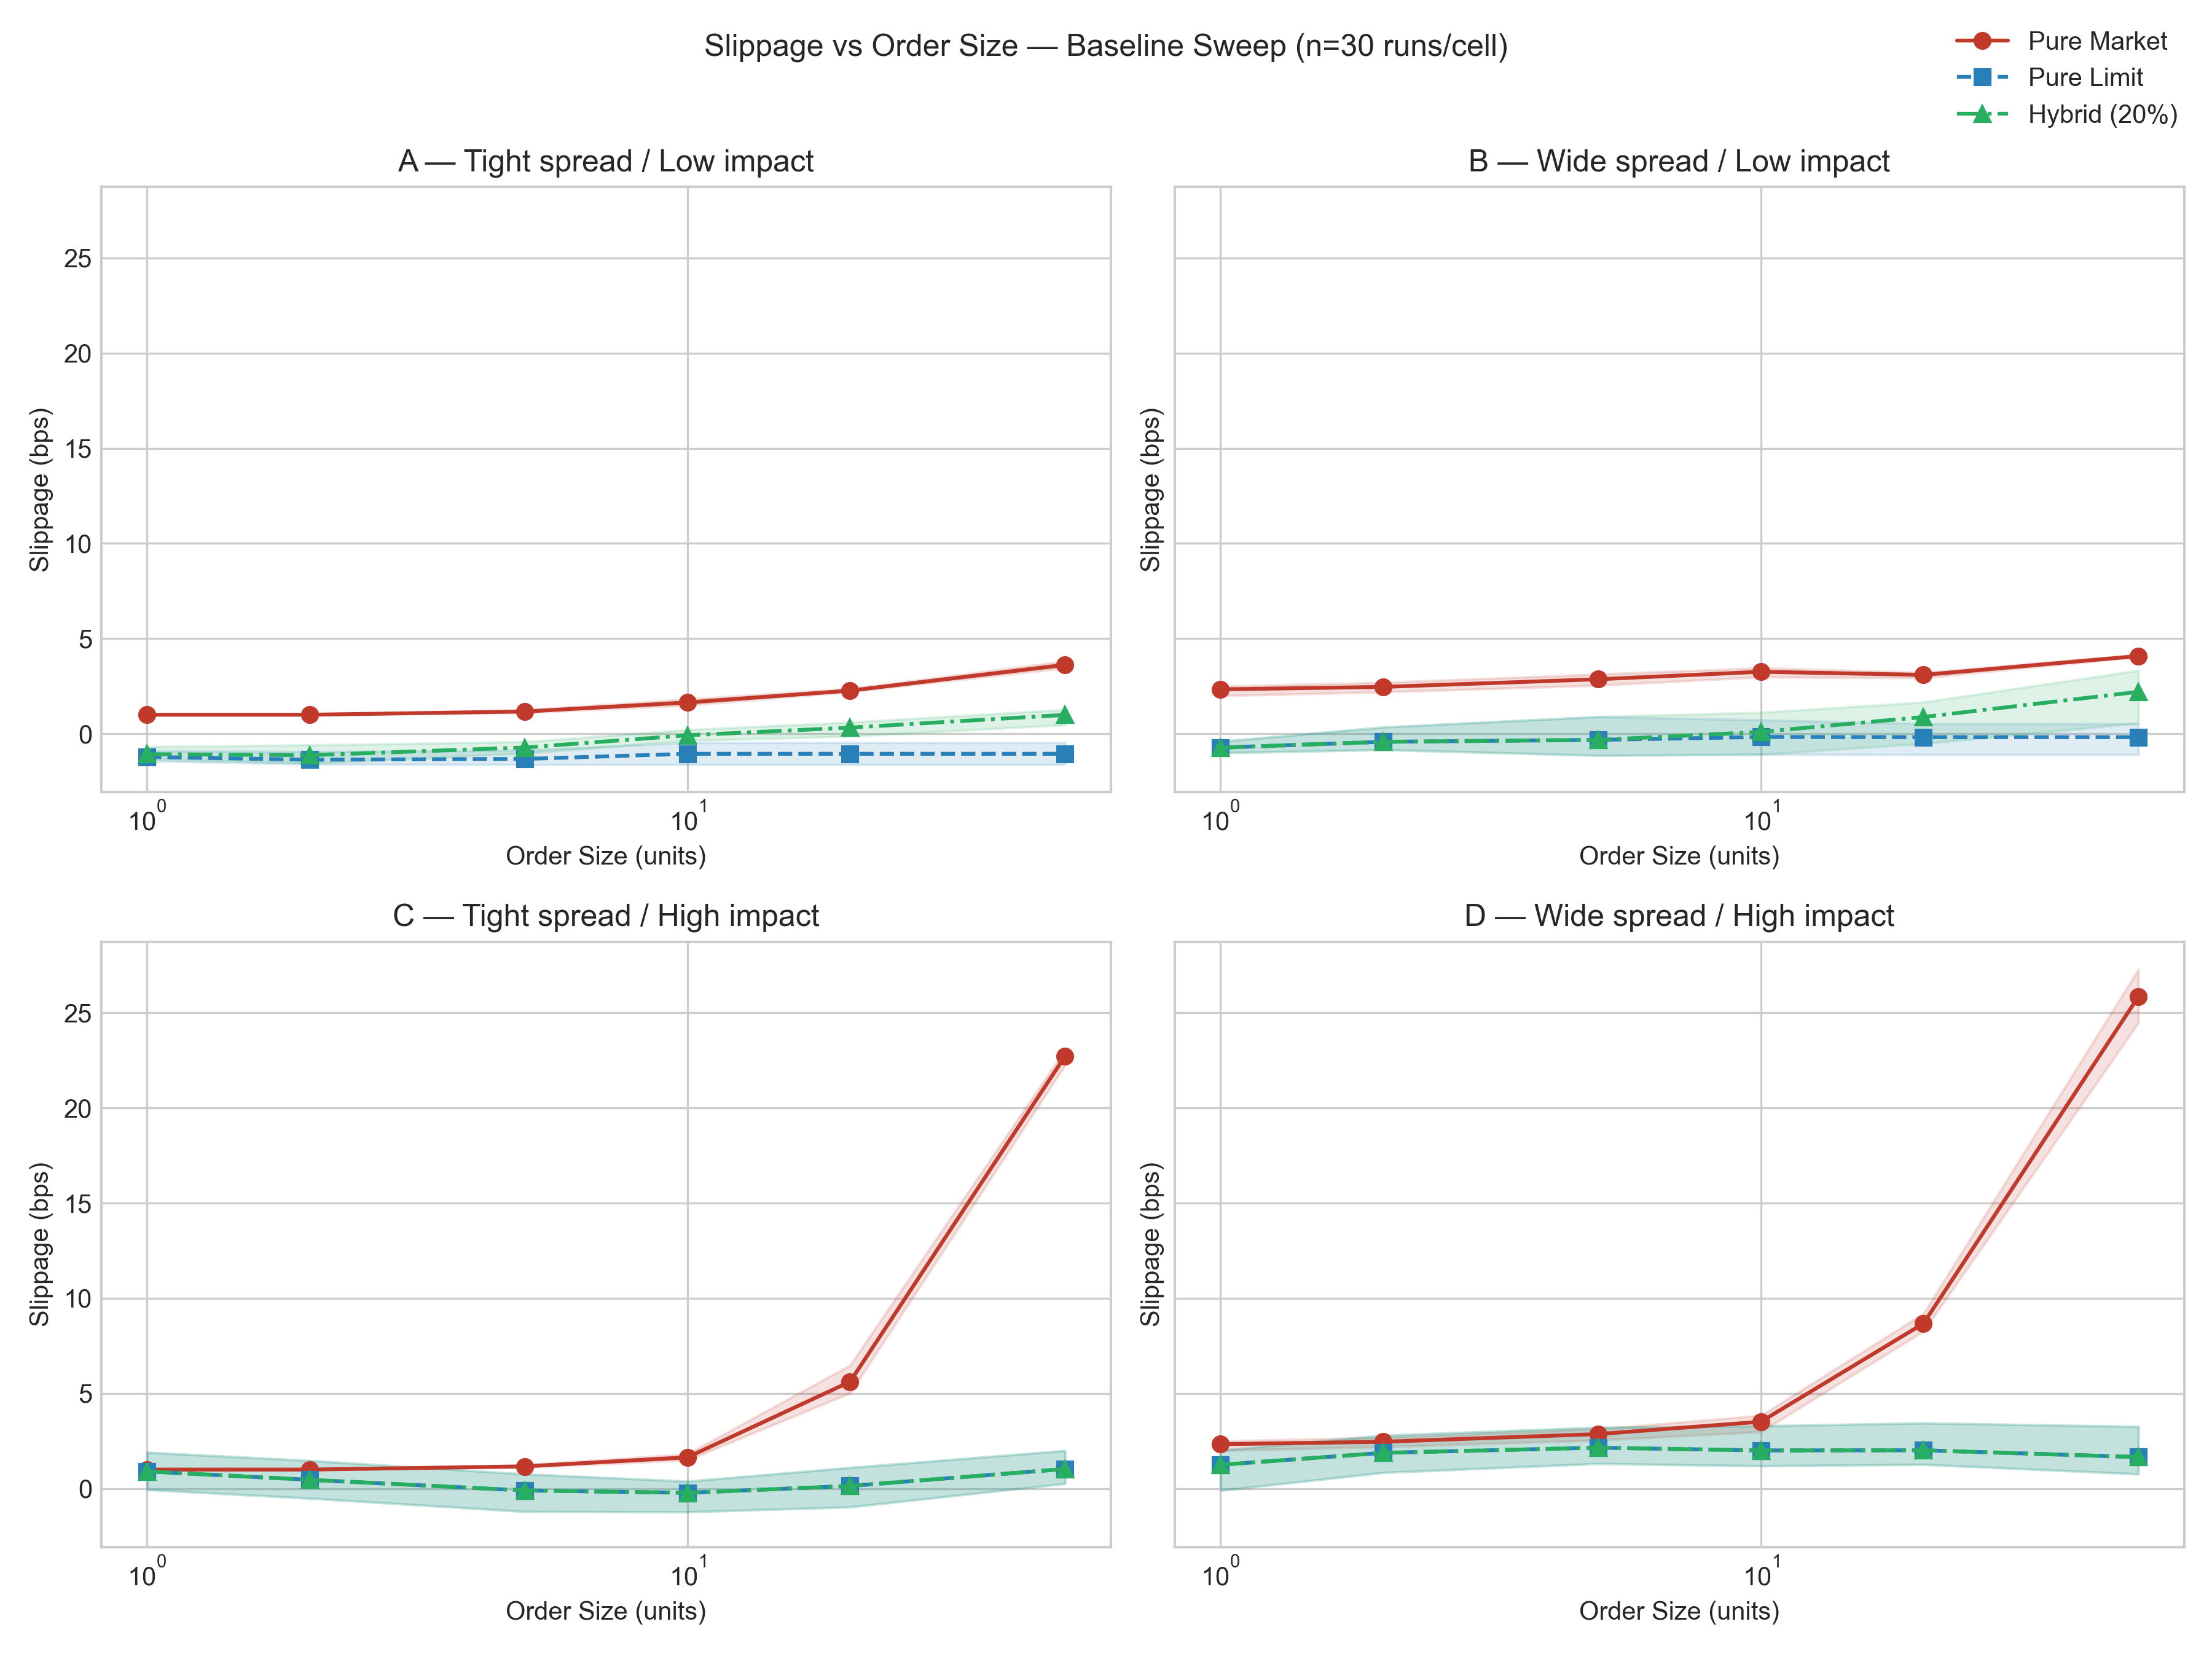

In [2]:
from lob_simulator.charts import plot_slippage_vs_size
import matplotlib.pyplot as plt
from IPython.display import Image, display

chart_path = Path("charts/slippage_vs_size.png")
plot_slippage_vs_size(df, output_path=chart_path)
display(Image(filename=str(chart_path), width=800))

## 5. Game-Theory Payoff & Equilibrium

In [3]:
from lob_simulator.game_theory import build_payoff_matrix, PayoffParams, IMPACT_LEVELS
import yaml

with open("configs/regimes.yaml") as f:
    cfg_yaml = yaml.safe_load(f)
regimes_dict = cfg_yaml["regimes"]

params = PayoffParams()
matrix = build_payoff_matrix(df, regimes_dict, order_size=5.0, params=params)
matrix.to_csv("results/strategic_regimes_table.csv", index=False)

# Display the payoff matrix
display_cols = ["regime", "lp_action", "lt_strategy", "impact_level", "U_LT", "U_LP", "is_equilibrium"]
matrix[display_cols]

,regime,lp_action,lt_strategy,impact_level,U_LT,U_LP,is_equilibrium
0,regime_A,tight_quote,pure_market,low,-0.011677,0.000000,False
1,regime_A,tight_quote,pure_limit,low,0.013217,0.000314,False
2,regime_A,tight_quote,hybrid,low,0.007223,0.000000,False
3,regime_B,wide_quote,pure_market,low,-0.028647,0.100000,False
4,regime_B,wide_quote,pure_limit,low,0.003217,0.101060,True
5,regime_B,wide_quote,hybrid,low,0.003217,0.101060,False
6,regime_C,tight_quote,pure_market,high,-0.011677,-0.225000,False
7,regime_C,tight_quote,pure_limit,high,0.000977,-0.225000,False
8,regime_C,tight_quote,hybrid,high,0.000977,-0.225000,False
9,regime_D,wide_quote,pure_market,high,-0.028647,-0.125000,False


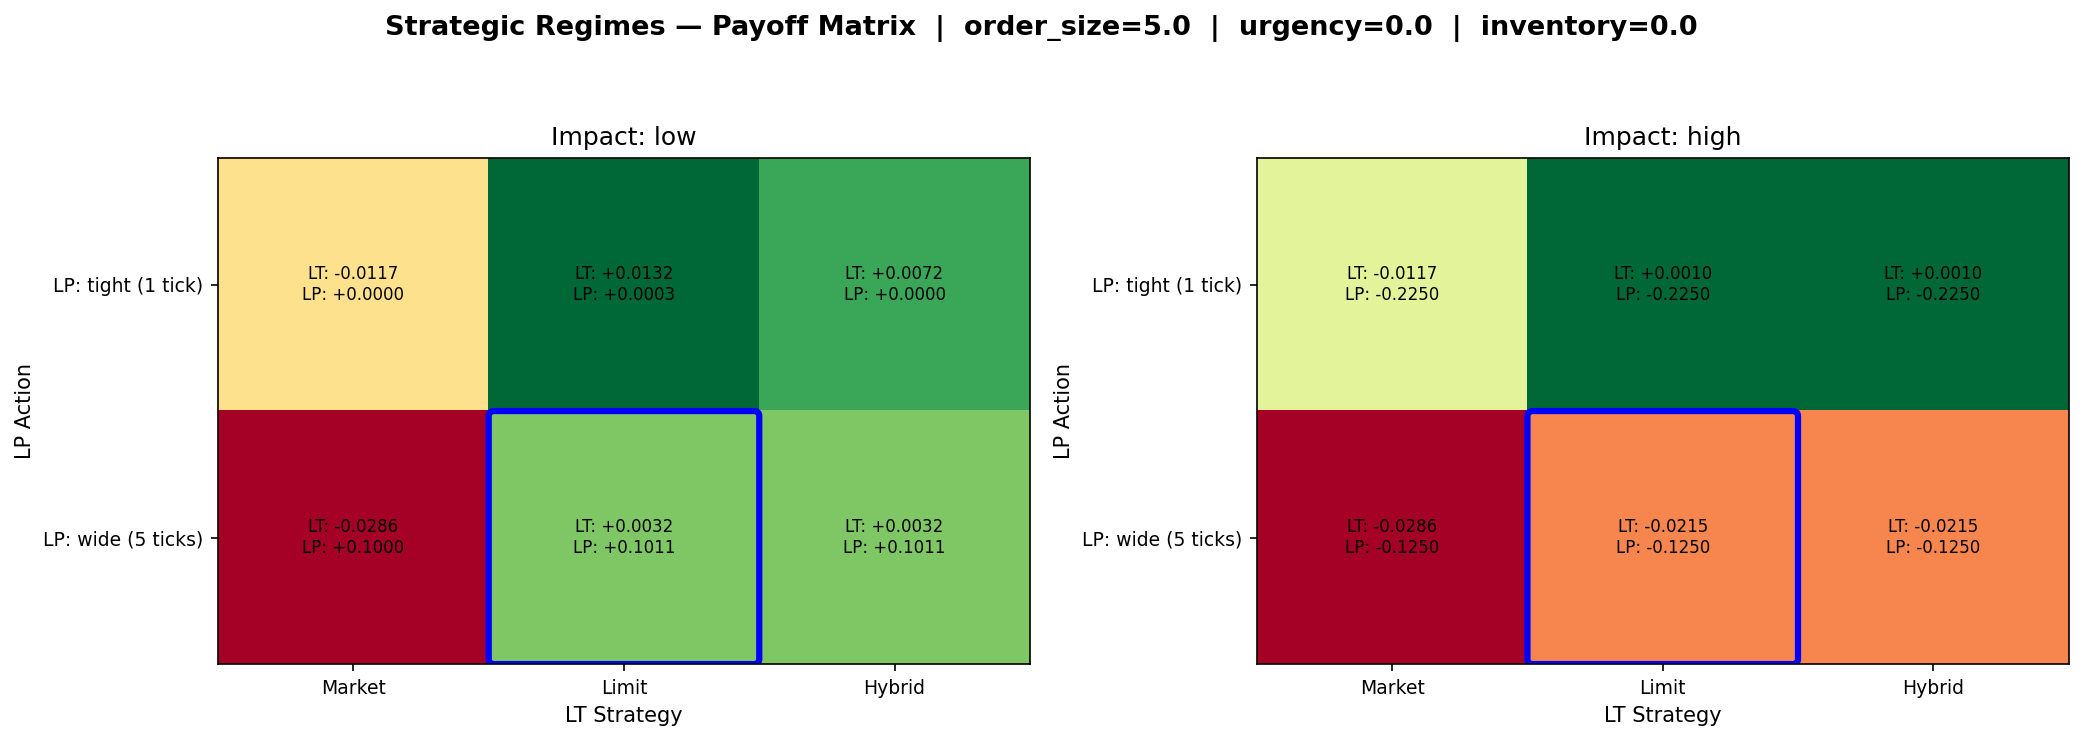

In [4]:
# Show the game theory heatmap chart
gt_chart = Path("charts/strategic_regimes_table.png")
if gt_chart.exists():
    display(Image(filename=str(gt_chart), width=800))

## 6. Equilibrium Narrative

In [5]:
for impact in IMPACT_LEVELS:
    eq = matrix[(matrix["impact_level"] == impact) & matrix["is_equilibrium"]]
    if eq.empty:
        print(f"{impact.upper()} impact: No pure-strategy Nash equilibrium found.")
    else:
        for _, row in eq.iterrows():
            print(
                f"{impact.upper()} impact: NE at LP={row['lp_action']}, "
                f"LT={row['lt_strategy']} "
                f"(U_LT={row['U_LT']:+.4f}, U_LP={row['U_LP']:+.4f})"
            )

low_eq = matrix[(matrix["impact_level"] == "low") & matrix["is_equilibrium"]]
high_eq = matrix[(matrix["impact_level"] == "high") & matrix["is_equilibrium"]]
if not low_eq.empty and not high_eq.empty:
    low_strats = set(low_eq["lt_strategy"])
    high_strats = set(high_eq["lt_strategy"])
    if low_strats != high_strats:
        print("=> Equilibrium SHIFTS across impact levels (strategy flip confirmed).")
    else:
        print("=> Same LT strategy in equilibrium across impact levels; "
              "payoff magnitudes differ due to higher execution costs under high impact.")

LOW impact: NE at LP=wide_quote, LT=pure_limit (U_LT=+0.0032, U_LP=+0.1011)
HIGH impact: NE at LP=wide_quote, LT=pure_limit (U_LT=-0.0215, U_LP=-0.1250)
=> Same LT strategy in equilibrium across impact levels; payoff magnitudes differ due to higher execution costs under high impact.


## 7. Limitations

This is a toy model. Key limitations include:
1. Single strategic agent (no endogenous LP response)
2. Time-sliced discretisation (not HFT-scale)
3. Linear memoryless impact (no Almgren-Chriss)
4. No empirical calibration
5. Closed-form LP payoff proxy

See the full [10-point limitations section in README.md](../README.md#limitations-vs-real-microstructure).